In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import operator
import time
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE

In [2]:
df = pd.read_csv('adult.data', sep=',', skipinitialspace=True, header=None, names=['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'])

# Zapoznanie ze zbiorem danych

In [3]:
df.head(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [4]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
df.shape

(32561, 15)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [7]:
df.columns.tolist()

['age',
 'workclass',
 'fnlwgt',
 'education',
 'education-num',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'native-country',
 'income']

In [8]:
df = df.replace(to_replace='?', value=np.nan)

In [9]:
df['income'].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [10]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

# Poniżej można zobaczyć jak rozkładają się dane liczbowo dla klas w poszczególnych kolumnach (cechach) kategorialnych.

In [11]:
value_counts_all_columns = {}

for column in df.columns:
    if df[column].dtype == 'str':
        value_counts_all_columns[column] = df[column].value_counts().to_dict()

for key in value_counts_all_columns.keys():
    print(f'Rozkład danych dla kolumny \'{key}\': ')
    sum_all_class_values = sum(list(value_counts_all_columns[key].values()))
    for idx, (key2, value2) in enumerate(value_counts_all_columns[key].items()):
        print(f'{idx+1}. \'{key2}\': {value2} ({((value2/sum_all_class_values)*100):.3f}%)', end='')
        if idx != len(value_counts_all_columns[key].keys()) - 1:
            print(';')
        else:
            print('.')
    print()

Rozkład danych dla kolumny 'workclass': 
1. 'Private': 22696 (73.868%);
2. 'Self-emp-not-inc': 2541 (8.270%);
3. 'Local-gov': 2093 (6.812%);
4. 'State-gov': 1298 (4.225%);
5. 'Self-emp-inc': 1116 (3.632%);
6. 'Federal-gov': 960 (3.124%);
7. 'Without-pay': 14 (0.046%);
8. 'Never-worked': 7 (0.023%).

Rozkład danych dla kolumny 'education': 
1. 'HS-grad': 10501 (32.250%);
2. 'Some-college': 7291 (22.392%);
3. 'Bachelors': 5355 (16.446%);
4. 'Masters': 1723 (5.292%);
5. 'Assoc-voc': 1382 (4.244%);
6. '11th': 1175 (3.609%);
7. 'Assoc-acdm': 1067 (3.277%);
8. '10th': 933 (2.865%);
9. '7th-8th': 646 (1.984%);
10. 'Prof-school': 576 (1.769%);
11. '9th': 514 (1.579%);
12. '12th': 433 (1.330%);
13. 'Doctorate': 413 (1.268%);
14. '5th-6th': 333 (1.023%);
15. '1st-4th': 168 (0.516%);
16. 'Preschool': 51 (0.157%).

Rozkład danych dla kolumny 'marital-status': 
1. 'Married-civ-spouse': 14976 (45.994%);
2. 'Never-married': 10683 (32.809%);
3. 'Divorced': 4443 (13.645%);
4. 'Separated': 1025 (3.148%)

# Kolumna 'education' oraz 'education-num' reprezentują tą samą wartość. Kolumna numeryczna jest oznaczona w kolejności od najniższego stopnia edukacji do najwyższego, więc nie trzeba używać one-hot encoding.

In [12]:
# https://realpython.com/sort-python-dictionary/
education = {x: y for x, y in zip(df['education'], df['education-num'])}
education = dict(sorted(education.items(), key=lambda item: item[1]))
education

{'Preschool': 1,
 '1st-4th': 2,
 '5th-6th': 3,
 '7th-8th': 4,
 '9th': 5,
 '10th': 6,
 '11th': 7,
 '12th': 8,
 'HS-grad': 9,
 'Some-college': 10,
 'Assoc-voc': 11,
 'Assoc-acdm': 12,
 'Bachelors': 13,
 'Masters': 14,
 'Prof-school': 15,
 'Doctorate': 16}

# Cechy: 'income' oraz 'sex' mają tylko 2 wartości, więc można podmienić na wartości numeryczne bez one-hot encoding.

In [13]:
le = LabelEncoder()
df['income'] = le.fit_transform(df['income'])

In [14]:
le2 = LabelEncoder()
df['sex'] = le2.fit_transform(df['sex'])

# Cechy do usunięcia: 'native-country' - zbyt dużo zmiennych, większość klas (39/41) ma ilość próbek poniżej 1% wszystkich próbek; 'education' - redundancja (ma zbyt duży związek z inną cechą), dosłownie jest odpowiednikiem kolumny 'education-num' tylko jedna w wersji kategorialnej, a druga zakodowana w wersji numerycznej; 'fnlwgt' - waga statystyczna próbki, nie powinna być używana do predykcji.

In [15]:
df = df.drop(columns=['native-country', 'education', 'fnlwgt'])

# Wypełnienie brakujących wartości kategorialnych jako 'Unknown', nowa klasa dla cech.

In [16]:
df = df.replace(to_replace=np.nan, value='Unknown')

# One-hot encoding dla cech kategorialnych, które nie można uszeregować klas oraz jest ich więcej niż 2.

In [17]:
df = pd.get_dummies(df, columns=['workclass', 'marital-status', 'occupation', 'relationship', 'race'])

# Podział danych na train i test

In [18]:
X = df.drop('income', axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
execution_time = {}

# Random Forest

In [20]:
start_time = time.time()
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)
end_time = time.time()
execution_time['Random Forest'] = end_time - start_time

In [21]:
y_pred_rf = model_rf.predict(X_test)

print('Dokładność (Accuracy Score):', accuracy_score(y_test, y_pred_rf))
print('Macierz pomyłek (Confusion Matrix):\n', confusion_matrix(y_test, y_pred_rf))
print('Raport', classification_report(y_test, y_pred_rf))

Dokładność (Accuracy Score): 0.8506064793489944
Macierz pomyłek (Confusion Matrix):
 [[4541  404]
 [ 569  999]]
Raport               precision    recall  f1-score   support

           0       0.89      0.92      0.90      4945
           1       0.71      0.64      0.67      1568

    accuracy                           0.85      6513
   macro avg       0.80      0.78      0.79      6513
weighted avg       0.85      0.85      0.85      6513



# Feature importances: na wykresie można zobaczyć najważniejsze cechy według Random Forest, m.in. 'age', 'education-num', 'hours-per-week', 'capital-gain', 'marital-status_Married_civ-spouse' itd.

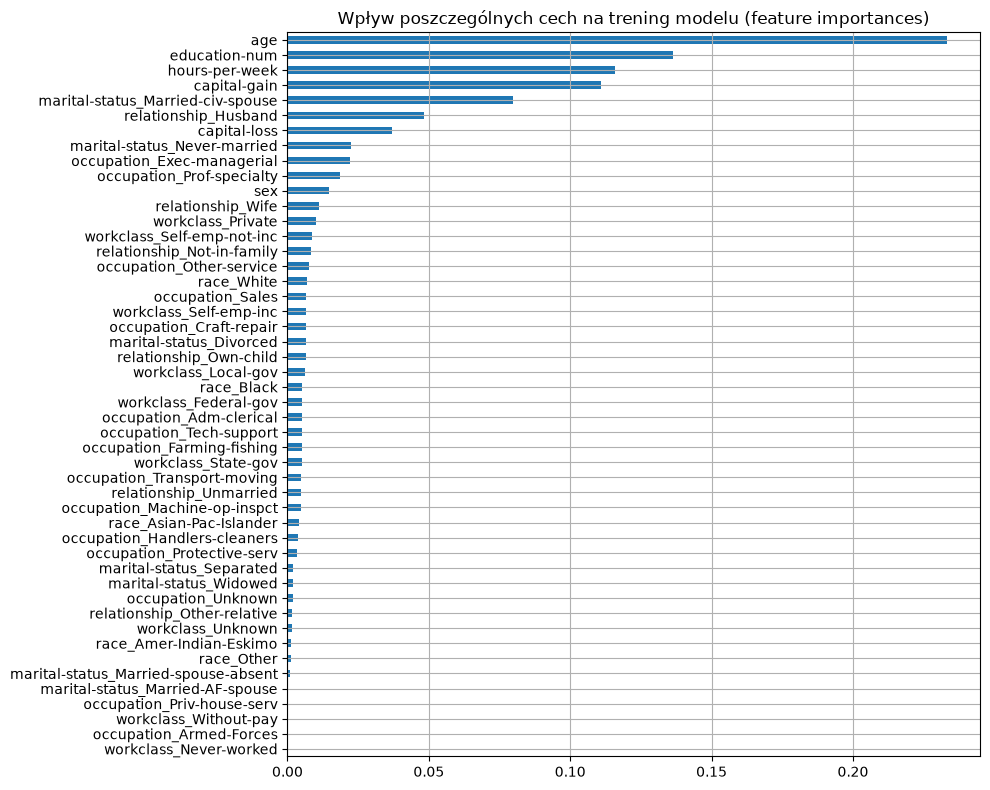

In [22]:
forest_importances = pd.Series(model_rf.feature_importances_, index=X.columns)
forest_importances_sorted = pd.Series(dict(sorted(forest_importances.to_dict().items(), key=operator.itemgetter(1))))

fig, ax = plt.subplots(figsize=(10, 8))

forest_importances_sorted.plot.barh()
ax.set_title('Wpływ poszczególnych cech na trening modelu (feature importances)')
ax.grid()
plt.tight_layout()
plt.show()

# SelectKBest

## Ocenia jakie cechy związane są z targetem za pomocą wzoru wybranego w 'score_func'. 'mutual_info_classif' - oblicza wzajemną informację pomiędzy dwiema zmiennymi dyskretnymi, używa wzoru na entropie.

In [23]:
# https://www.kaggle.com/discussions/getting-started/561989
# https://www.geeksforgeeks.org/machine-learning/feature-selection-in-python-with-scikit-learn/
models_rf_select_k_best = {}
columns_select_k_best = {}

for k in range(5, 21, 1):
    start_time = time.time()
    k_best_selector = SelectKBest(score_func=mutual_info_classif, k=k)
    k_best_selector.fit_transform(X_train, y_train)
    columns_select_k_best[f'SelectKBest k = {k}'] = X_train.columns[k_best_selector.get_support()]
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train[X_train.columns[k_best_selector.get_support()]], y_train)
    models_rf_select_k_best[f'Random Forest + SelectKBest k = {k}'] = model
    end_time = time.time()
    execution_time[f'Random Forest: SelectKBest k = {k}'] = end_time - start_time

## Na wykresie widać zmieniające się Accuracy Score w zależności od ilości wyznaczonych cech dla SelectKBest. Najlepszy wynik osiągnął model po wyborze 10 cech przez SelectKBest. Wynik jest trochę gorszy od treningu modelu na wszystkich cechach.

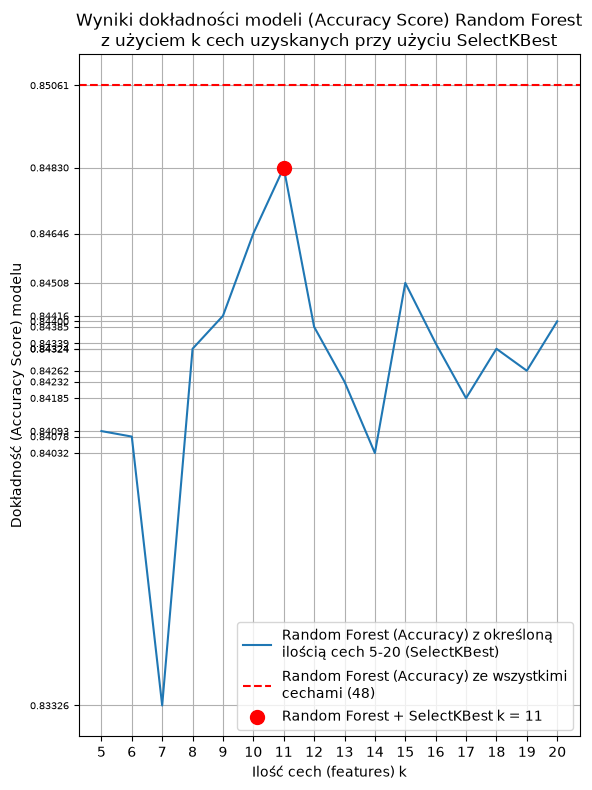

In [24]:
models_rf_select_k_best_accuracy_score = {
    f'Random Forest + SelectKBest k = {k}': accuracy_score(
        y_test,
        models_rf_select_k_best[f'Random Forest + SelectKBest k = {k}'].predict(
            X_test[columns_select_k_best[f'SelectKBest k = {k}']]
        )
    )
    for k in range(5, 21, 1)
}

best_value_select_k_best = sorted(models_rf_select_k_best_accuracy_score, key=models_rf_select_k_best_accuracy_score.get, reverse=True)[0]

plt.figure(figsize=(6, 8))

plt.plot(range(5, 21, 1), models_rf_select_k_best_accuracy_score.values(), label='Random Forest (Accuracy) z określoną\nilością cech 5-20 (SelectKBest)')
plt.axhline(y=accuracy_score(y_test, y_pred_rf), color='r', linestyle='--', label='Random Forest (Accuracy) ze wszystkimi\ncechami (48)')
plt.scatter(int(best_value_select_k_best.split()[::-1][0]), models_rf_select_k_best_accuracy_score[best_value_select_k_best], color='r', s=100, zorder=5, label=best_value_select_k_best)
plt.title('Wyniki dokładności modeli (Accuracy Score) Random Forest\nz użyciem k cech uzyskanych przy użyciu SelectKBest')
plt.xlabel('Ilość cech (features) k')
plt.ylabel('Dokładność (Accuracy Score) modelu')
plt.xticks(range(5, 21, 1))
plt.yticks(list(models_rf_select_k_best_accuracy_score.values()) + [accuracy_score(y_test, y_pred_rf)], fontsize=7)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# RFE

## Eliminuje mniej ważne cechy poprzez trening wielu modeli, usuwa mało ważną cechę i kontynuuje proces, aż nie zostanie określona liczba cech.

In [25]:
models_rf_rfe = {}
columns_rfe = {}

for k in range(5, 21, 1):
    start_time = time.time()
    rfe_selector = RFE(estimator=RandomForestClassifier(random_state=42), n_features_to_select=k)
    rfe_selector.fit_transform(X_train, y_train)
    columns_rfe[f'RFE k = {k}'] = X_train.columns[rfe_selector.get_support()]
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train[X_train.columns[rfe_selector.get_support()]], y_train)
    models_rf_rfe[f'Random Forest + RFE k = {k}'] = model
    end_time = time.time()
    execution_time[f'Random Forest: RFE k = {k}'] = end_time - start_time

## Na wykresie widać zmieniające się Accuracy Score w zależności od ilości wyznaczonych cech dla RFE. Najlepszy wynik osiągnął model po wyborze 16 cech przez RFE. Wynik jest trochę gorszy od treningu modelu na wszystkich cechach.

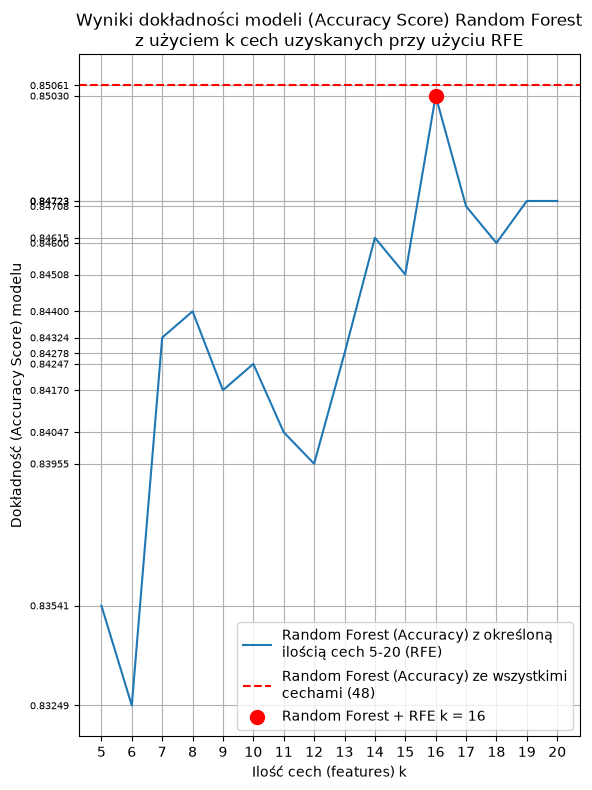

In [26]:
models_rf_rfe_accuracy_score = {
    f'Random Forest + RFE k = {k}': accuracy_score(
        y_test,
        models_rf_rfe[f'Random Forest + RFE k = {k}'].predict(
            X_test[columns_rfe[f'RFE k = {k}']]
        )
    )
    for k in range(5, 21, 1)
}

best_value_rfe = sorted(models_rf_rfe_accuracy_score, key=models_rf_rfe_accuracy_score.get, reverse=True)[0]

plt.figure(figsize=(6, 8))

plt.plot(range(5, 21, 1), models_rf_rfe_accuracy_score.values(), label='Random Forest (Accuracy) z określoną\nilością cech 5-20 (RFE)')
plt.axhline(y=accuracy_score(y_test, y_pred_rf), color='r', linestyle='--', label='Random Forest (Accuracy) ze wszystkimi\ncechami (48)')
plt.scatter(int(best_value_rfe.split()[::-1][0]), models_rf_rfe_accuracy_score[best_value_rfe], color='r', s=100, zorder=5, label=best_value_rfe)
plt.title('Wyniki dokładności modeli (Accuracy Score) Random Forest\nz użyciem k cech uzyskanych przy użyciu RFE')
plt.xlabel('Ilość cech (features) k')
plt.ylabel('Dokładność (Accuracy Score) modelu')
plt.xticks(range(5, 21, 1))
plt.yticks(list(models_rf_rfe_accuracy_score.values()) + [accuracy_score(y_test, y_pred_rf)], fontsize=7)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Wykres poglądowy dla Accuracy: SelectBKest oraz RFE. Na wykresie widać, że największa wartość dla RFE jest blisko osiągnięcia tak samo dobrego wyniku (Accuracy) na treningu modelu na 16 cechach, co trenowanie modelu na wszystkich cechach (48) - 85.06%. Najlepszy wynik RFE (k = 16) - 85.02% widocznie przewyższa najlepszy wynik SelectKBest (k = 10) - 84.64%.

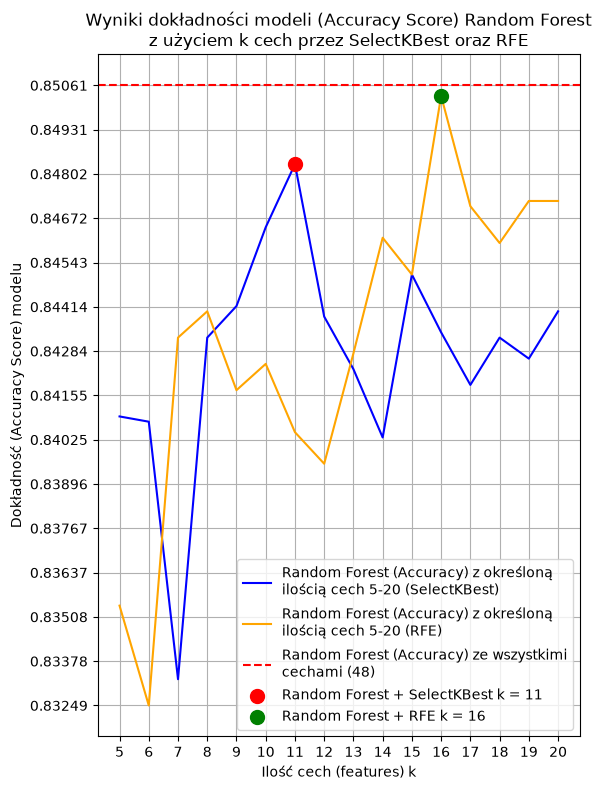

In [27]:
all_accuracy_score_results = list(models_rf_rfe_accuracy_score.values()) + list(models_rf_select_k_best_accuracy_score.values()) + [accuracy_score(y_test, y_pred_rf)]

plt.figure(figsize=(6, 8))

plt.plot(range(5, 21, 1), models_rf_select_k_best_accuracy_score.values(), label='Random Forest (Accuracy) z określoną\nilością cech 5-20 (SelectKBest)', color='blue')
plt.plot(range(5, 21, 1), models_rf_rfe_accuracy_score.values(), label='Random Forest (Accuracy) z określoną\nilością cech 5-20 (RFE)', color='orange')
plt.axhline(y=accuracy_score(y_test, y_pred_rf), color='r', linestyle='--', label='Random Forest (Accuracy) ze wszystkimi\ncechami (48)')
plt.scatter(int(best_value_select_k_best.split()[::-1][0]), models_rf_select_k_best_accuracy_score[best_value_select_k_best], color='r', s=100, zorder=5, label=best_value_select_k_best)
plt.scatter(int(best_value_rfe.split()[::-1][0]), models_rf_rfe_accuracy_score[best_value_rfe], color='g', s=100, zorder=5, label=best_value_rfe)
plt.title('Wyniki dokładności modeli (Accuracy Score) Random Forest\nz użyciem k cech przez SelectKBest oraz RFE')
plt.xlabel('Ilość cech (features) k')
plt.ylabel('Dokładność (Accuracy Score) modelu')
plt.xticks(range(5, 21, 1))
plt.yticks(np.linspace(min(all_accuracy_score_results), max(all_accuracy_score_results), 15), fontsize=10)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Wyniki w tabelach jasno pokazują, że trening z szukaniem odpowiednich cech dla SelectKBest trwa znacznie krócej niż dla RFE, mimo że modele RFE mają nieco lepsze wyniki (Accuracy).

## Wyniki treningu modelu w postaci ramki danych (DataFrame).

In [28]:
models_summary = pd.concat(
    [
        pd.DataFrame(
            {
                'Model': (
                    ['Random Forest'] +
                    list(models_rf_select_k_best.keys()) +
                    list(models_rf_rfe.keys())
                ),
                'Liczba Cech (k)': (
                    [X_train.shape[1]] +
                    [k.split()[::-1][0] for k in models_rf_select_k_best.keys()] +
                    [k.split()[::-1][0] for k in models_rf_rfe.keys()]
                ),
                'Accuracy Score': (
                    [accuracy_score(y_test, y_pred_rf)] +
                    list(models_rf_select_k_best_accuracy_score.values()) +
                    list(models_rf_rfe_accuracy_score.values())
                ),
                'Czas Treningu': [time.strftime('%M minut %S sekund', time.gmtime(x)) for x in list(execution_time.values())]
            }
        )
    ],
    ignore_index=True
)

models_summary

,Model,Liczba Cech (k),Accuracy Score,Czas Treningu
0,Random Forest,48,0.850606,00 minut 03 sekund
1,Random Forest + SelectKBest k = 5,5,0.840934,00 minut 09 sekund
2,Random Forest + SelectKBest k = 6,6,0.840780,00 minut 09 sekund
3,Random Forest + SelectKBest k = 7,7,0.833257,00 minut 10 sekund
4,Random Forest + SelectKBest k = 8,8,0.843237,00 minut 09 sekund
5,Random Forest + SelectKBest k = 9,9,0.844158,00 minut 09 sekund
6,Random Forest + SelectKBest k = 10,10,0.846461,00 minut 10 sekund
7,Random Forest + SelectKBest k = 11,11,0.848303,00 minut 09 sekund
8,Random Forest + SelectKBest k = 12,12,0.843851,00 minut 10 sekund
9,Random Forest + SelectKBest k = 13,13,0.842315,00 minut 10 sekund


## Wyniki treningu modelu w postaci ramki danych (DataFrame) w kolejności od najlepszego wyniku (Accuracy Score) do najgorszego.

In [29]:
models_summary_sorted = pd.DataFrame(
    sorted(
        [
            {'Model': model_name,
             'Liczba Cech (k)': k,
             'Accuracy Score': model_accuracy_score,
             'Czas Treningu': time.strftime('%M minut %S sekund', time.gmtime(training_time))}
            for model_name, k, model_accuracy_score, training_time in zip(
                ['Random Forest'] +
                list(models_rf_select_k_best.keys()) +
                list(models_rf_rfe.keys()),
                [X_train.shape[1]] +
                [k.split()[::-1][0] for k in models_rf_select_k_best.keys()] +
                [k.split()[::-1][0] for k in models_rf_rfe.keys()],
                [accuracy_score(y_test, y_pred_rf)] +
                list(models_rf_select_k_best_accuracy_score.values()) +
                list(models_rf_rfe_accuracy_score.values()),
                list(execution_time.values())
            )
        ],
        key = lambda d: d['Accuracy Score'],
        reverse=True
    )
)

models_summary_sorted

,Model,Liczba Cech (k),Accuracy Score,Czas Treningu
0,Random Forest,48,0.850606,00 minut 03 sekund
1,Random Forest + RFE k = 16,16,0.850299,01 minut 34 sekund
2,Random Forest + SelectKBest k = 11,11,0.848303,00 minut 09 sekund
3,Random Forest + RFE k = 19,19,0.847229,01 minut 43 sekund
4,Random Forest + RFE k = 20,20,0.847229,01 minut 43 sekund
5,Random Forest + RFE k = 17,17,0.847075,01 minut 33 sekund
6,Random Forest + SelectKBest k = 10,10,0.846461,00 minut 10 sekund
7,Random Forest + RFE k = 14,14,0.846154,01 minut 37 sekund
8,Random Forest + RFE k = 18,18,0.846000,01 minut 37 sekund
9,Random Forest + SelectKBest k = 15,15,0.845079,00 minut 11 sekund
